Cycle 2

E-Mart wants to gain a better understanding of how It provides value to its customers. Based on customer understanding, the retailer will focus on increasing sales by creating messaging that resonates with target audience. In other words, **The ultimate goal of this project is being able to target our users differently given their current status**. 

Therefore, we need to identify customer personas and their value.

- **Who are our best customers?**

- **Where are they?**

- **Who has the potential to become valuable customers?**

- **Which of our customers are most likely to respond to engagement campaigns?**

- **Which of our customers can be retained?**


# Customer Segmentation - Machine Learning



## Agenda

[0 Imports](#0.0-Imports)<br>
&emsp;[0.1 Helper Functions](#0.1-Helper-Functions)<br>
&emsp;[0.2 Loading Data](#0.2-Loading-Data)<br>

[1 Clustering Algorithm](#1-Clustering-Algorithm)<br>
&emsp;[1.1 Feature Engineering](#1.1-Feature-Engineering)<br>
&emsp;[1.2 Feature Selection](#1.2-Feature-Selection)<br>
&emsp;[1.3 Modeling](#1.3-Modeling)<br>

[2 Analysis](#2-Analysis)<br>
&emsp;[2.1 Average Sales and Profit](#2.1-Average-Sales-and-Profit)<br>
&emsp;[2.2 Orders and Quantity of Products](#2.2-Orders-and-Quantity-of-Products)<br>
&emsp;[2.3 Recency and Frequency](#2.3-Recency-and-Frequency)<br>
&emsp;[2.4 Discount and Shipping Cost](#2.4-Discount-and-Shipping-Cost)<br>
&emsp;[2.5 Cluster 4*](#2.5-Cluster-4)<br>
&emsp;[2.6 Cluster 1*](#2.6-Cluster-1)<br>

[3 Random Forest](#3-Random-Forest)<br>

## 0 Imports

In [1]:
from data_science_lib.dir import Directory, join_paths
from data_science_lib.eda import describe_data
from data_science_lib.graph import fig

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from sklearn.model_selection import cross_validate

# Settings
directory = Directory("pr_v01_customer_segmentation", is_sub_project=True)
pd.set_option('display.max_columns', None)

%matplotlib inline

### 0.1 Helper Functions

In [2]:
def frequency_plot(segments):
    fig()
    plt.subplot(1, 2, 1)
    sns.scatterplot(x='frequency', y='value', hue='rfv_class', data=df, palette=get_rfv_palette(segments));
    plt.legend([]);
    plt.subplot(1, 2, 2)
    sns.scatterplot(x='frequency_rank', y='value_rank', hue='rfv_class', data=df, palette=get_rfv_palette(segments));
    plt.legend(loc=(1.05, .5));
    plt.show()
    
def recency_plot(segments):
    fig()
    plt.subplot(1, 2, 1)
    sns.scatterplot(x='recency', y='value', hue='rfv_class', data=df, palette=get_rfv_palette(segments));
    plt.legend([]);
    plt.subplot(1, 2, 2)
    sns.scatterplot(x='recency_rank', y='value_rank', hue='rfv_class', data=df, palette=get_rfv_palette(segments));
    plt.legend(loc=(1.05, .5));
    plt.show()
    
    
def cluster_count_plot(data, cluster_col="cluster", palette='crest_r'):
    plt.box(False)
    ax = sns.countplot(y=cluster_col, data=data, palette=palette)
    plt.title('Quantity of Customers')
    plt.tick_params(axis='both', length=0)
    plt.xlabel(None)
    for p in ax.patches:
        ax.annotate('{:.0f}'.format(p.get_width()), (p.get_width()+5, p.get_y()+.5))

def compare_clusters(cluster, y, data, showfliers=False, xticks_rotation=0, figsize=(15, 5)):
    fig(figsize[0], figsize[1])
    plt.subplot( 1, 2, 1 )
    sns.boxplot( x=cluster, y=y[0], data=data, showfliers=showfliers)
    plt.xticks(rotation=xticks_rotation)
    plt.subplot( 1, 2, 2 )
    sns.boxplot( x=cluster, y=y[1], data=data, showfliers=showfliers)
    plt.xticks(rotation=xticks_rotation)
    

def cluster_stats(df, column, cluster='cluster', quantile_1=.8, quantile_2=.9):    
    stats = df.groupby(cluster)[[column]].describe()[column]
    quantiles = pd.concat([df.groupby(cluster)[[column]].quantile(quantile_1), df.groupby(cluster)[[column]].quantile(quantile_2)], axis=1)
    quantile_1_name, quantile_2_name = f'{round(quantile_1*100)}%', f'{round(quantile_2*100)}%'
    quantiles.columns = [quantile_1_name, quantile_2_name]
    stats = pd.concat([stats, quantiles], axis=1)
    return stats[['mean', 'std', 'min', '25%', '50%', '75%', quantile_1_name, quantile_2_name, 'max']]

### 0.2 Loading Data

In [3]:
raw_data = pd.read_parquet(join_paths([directory.DATA_DIR, "processed", "e_mart_customer_abt_2014.parquet"]))
raw_data.head(2)

,customer_id,orders,total_sales,quantity,total_profit,avg_discount,is_profitable_sale,total_shipping_cost,avg_ticket,distinct_products,avg_profit,avg_shipping_cost,recency,frequency,value,avg_value,recency_rank,frequency_rank,value_rank,avg_value_rank,rfv_class
0,AA-10315,7,3889.2065,53,534.2215,0.142857,0.642857,485.51,555.600929,17,76.317357,69.358571,9,7,3889.2065,228.776853,0.816347,0.621443,0.705493,0.614163,Loyal
1,AA-10375,7,1904.5380,52,674.5155,0.080952,0.857143,212.86,272.076857,14,96.359357,30.408571,7,7,1904.5380,136.038429,0.860688,0.621443,0.497684,0.337525,Loyal


In [4]:
describe_data(raw_data)

Shape: (1511, 21)
Duplicates: False


,data_types,nan_count,nan_percentage
customer_id,object,0,0.0
orders,int64,0,0.0
total_sales,float64,0,0.0
quantity,int64,0,0.0
total_profit,float64,0,0.0
avg_discount,float64,0,0.0
is_profitable_sale,float64,0,0.0
total_shipping_cost,float64,0,0.0
avg_ticket,float64,0,0.0
distinct_products,int64,0,0.0


## 1 Clustering Algorithm 

In [5]:
customer_abt = raw_data.copy()

### 1.1 Feature Engineering

_Feature Engineering step was done and saved during rfv segmentation._

### 1.2 Feature Selection

excluded = ['customer_id', 'rfv_class']

In [6]:
df = customer_abt.copy()
df.columns

Index(['customer_id', 'orders', 'total_sales', 'quantity', 'total_profit',
       'avg_discount', 'is_profitable_sale', 'total_shipping_cost',
       'avg_ticket', 'distinct_products', 'avg_profit', 'avg_shipping_cost',
       'recency', 'frequency', 'value', 'avg_value', 'recency_rank',
       'frequency_rank', 'value_rank', 'avg_value_rank', 'rfv_class'],
      dtype='object')

In [7]:
features = ['orders', 'total_sales', 'quantity', 'total_profit',
            'avg_discount', 'is_profitable_sale', 'total_shipping_cost',
            'avg_ticket', 'distinct_products', 'avg_profit', 'avg_shipping_cost',
            'recency', 'frequency', 'value', 'avg_value', 'recency_rank',
            'frequency_rank', 'value_rank', 'avg_value_rank']
all_features = features

features = ['total_sales', 'total_profit', 'avg_discount', 'avg_shipping_cost']

min_max_scaler = RobustScaler()
X = min_max_scaler.fit_transform(df[features])

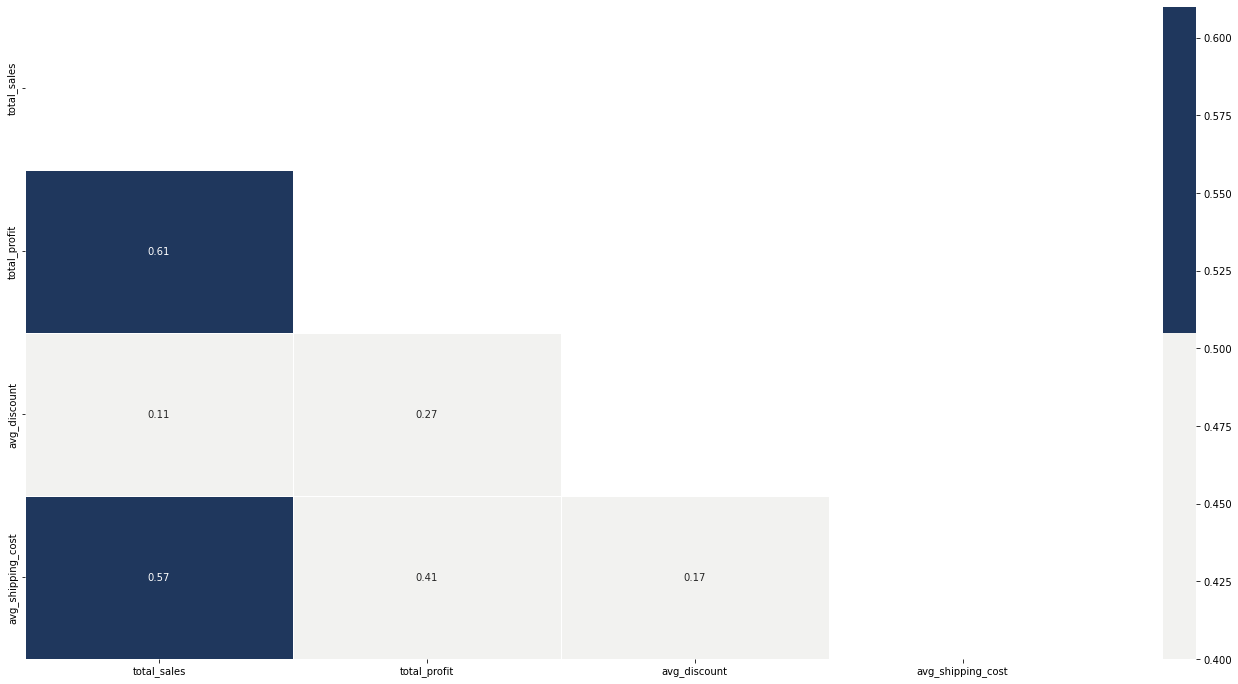

In [8]:
plt.figure(figsize=(24, 12))
correlations = df[features].corr().abs().round(2)
mask = np.triu(np.ones_like(correlations, dtype=bool))
sns.heatmap(correlations, mask=mask, linewidths=1, annot=True, cmap=['#F2F2F0','#1F375D'], vmin=0.40) # vmax=-0.40
plt.show()

In [9]:
# pd.DataFrame(X).hist(); # figsize=(15, 5), layout=(1,3), 
# df[features].hist();

### 1.3 Modeling

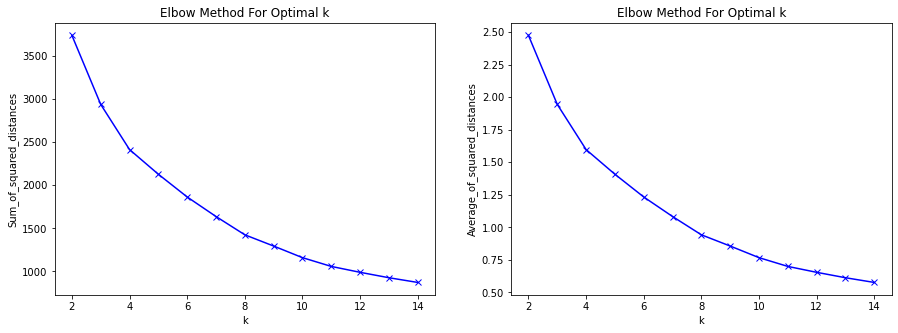

Wall time: 2.46 s


In [10]:
%%time
sum_of_squared_distances = []
average_of_squared_distances = []

K = range(2,15)
for k in K:
    km = KMeans(n_clusters=k, max_iter=500, random_state=42)
    km = km.fit(X)
    sum_of_squared_distances.append(km.inertia_) 
    
    distortion = ((X - km.cluster_centers_[km.predict(X)])**2.0).sum(axis=1).mean()
    average_of_squared_distances.append(distortion)
     
plt.figure(figsize=(15, 5))
plt.subplot( 1, 2, 1 )
plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.subplot( 1, 2, 2 )
plt.plot(K, average_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Average_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

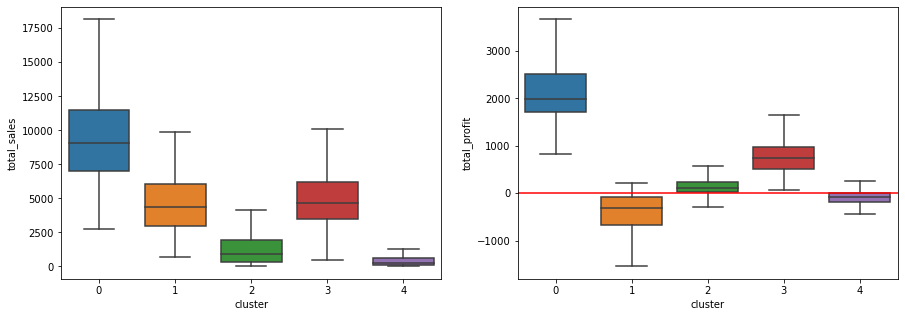

In [11]:
kmeans = KMeans(n_clusters=5, max_iter=500, random_state=42)
labels = kmeans.fit_predict(X)
customer_abt['cluster'] = labels

compare_clusters( cluster='cluster', y=['total_sales', 'total_profit'], data=customer_abt, showfliers=0)
plt.axhline(0, color='r');

## 2 Analysis

- **0**<br>

        Avg Sales: $ 1,250
        Avg Profit: $ 320
        Avg Discount: 8%
        Avg Shipping Cost: $ 137
        Avg Recency: 41 days
        Avg Number of Orders: 9
       
       
- **1**<br>

        Avg Sales: $ 624
        Avg Profit: $ -81
        Avg Discount: 21%
        Avg Shipping Cost: $ 71
        Avg Recency: 40 days
        Avg Number of Orders: 8
        
        
- **2**<br>

        Avg Sales: $ 260
        Avg Profit: $ 37
        Avg Discount: 8%
        Avg Shipping Cost: $ 25
        Avg Recency: 74 days
        Avg Number of Orders: 4
        
        
- **3**<br>

        Avg Sales: $ 646
        Avg Profit: $ 118
        Avg Discount: 11%
        Avg Shipping Cost: $ 71
        Avg Recency: 42 days
        Avg Number of Orders: 8
        
        
- **4**<br>

        Avg Sales: $ 171
        Avg Profit: $ -74
        Avg Discount: 43%
        Avg Shipping Cost: $ 16
        Avg Recency: 111 days
        Avg Number of Orders: 2


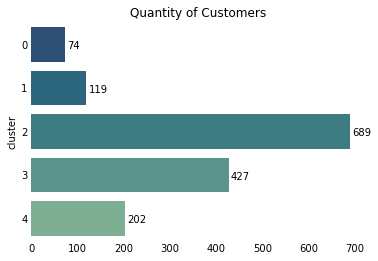

In [12]:
cluster_count_plot(customer_abt, cluster_col='cluster')

### 2.1 Average Sales and Profit

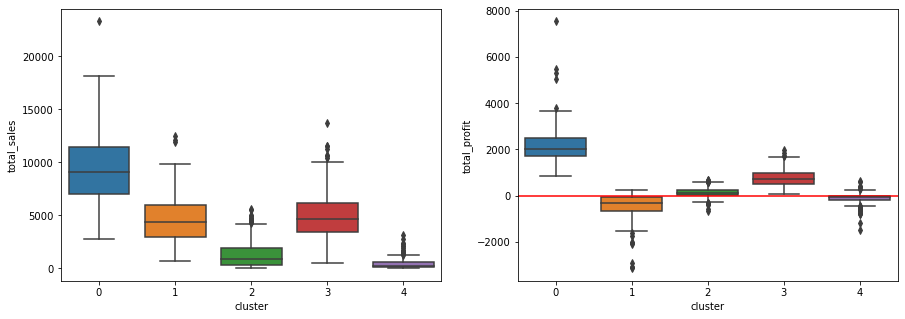

In [13]:
compare_clusters( cluster='cluster', y=['total_sales', 'total_profit'], data=customer_abt, showfliers=1)
plt.axhline(0, color='r');

In [14]:
cluster_stats(customer_abt, cluster='cluster', column='total_sales').sort_values('mean', ascending=False)

,mean,std,min,25%,50%,75%,80%,90%,max
cluster,,,,,,,,,
0,9430.517777,3565.856144,2766.480,7016.49000,9057.76860,11494.67130,11835.553600,12885.467856,23295.2184
3,4888.681349,2124.417301,493.620,3457.43500,4666.73880,6185.45220,6615.593004,7696.297108,13724.1870
1,4695.479780,2378.009105,682.422,2979.76995,4343.77754,6023.07096,6456.983480,8177.839140,12512.8473
2,1254.905724,1131.485126,6.030,339.18000,905.21400,1921.47200,2223.971400,2926.035200,5591.7105
4,451.230105,534.165540,2.052,108.45000,274.16550,589.63200,714.548400,1077.651000,3108.3660


In [36]:
cluster_stats(customer_abt, cluster='cluster', column='avg_profit').sort_values('mean', ascending=False)

,mean,std,min,25%,50%,75%,80%,90%,max
cluster,,,,,,,,,
0,320.953871,241.056609,74.198612,174.043834,240.258710,320.661162,388.395062,680.288049,1241.4900
3,118.177397,100.525204,8.620820,62.928079,92.318423,135.277077,150.677981,207.913600,884.4600
2,37.965819,51.049755,-194.424000,9.030000,29.550000,57.376090,64.324560,99.918500,350.3100
4,-74.272194,169.410265,-1472.376000,-94.388375,-33.731500,-2.968500,4.653000,24.934320,195.4605
1,-81.033952,157.674372,-1013.601000,-83.444689,-34.069844,-10.562784,-3.473733,4.954905,113.2200


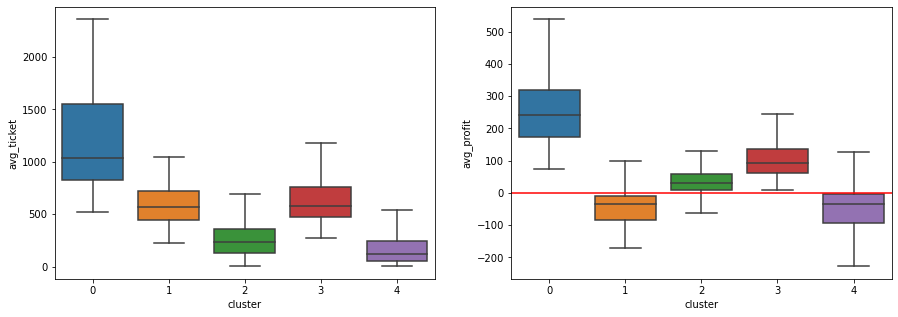

In [16]:
compare_clusters( cluster='cluster', y=['avg_ticket', 'avg_profit'], data=customer_abt, showfliers=0)
plt.axhline(0, color='r');

### 2.2 Orders and Quantity of Products

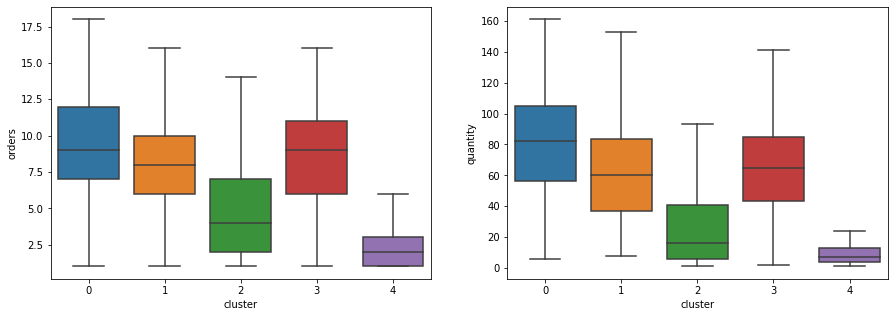

In [17]:
compare_clusters( cluster='cluster', y=['orders', 'quantity'], data=customer_abt, showfliers=0);

In [43]:
cluster_stats(customer_abt, cluster='cluster', column='orders').sort_values('mean', ascending=False)

,mean,std,min,25%,50%,75%,80%,90%,max
cluster,,,,,,,,,
0,9.243243,4.443899,1.0,7.0,9.0,12.0,12.4,15.0,21.0
3,8.327869,3.485078,1.0,6.0,9.0,11.0,11.0,13.0,16.0
1,8.000000,3.389915,1.0,6.0,8.0,10.0,10.4,12.2,17.0
2,4.611030,3.216002,1.0,2.0,4.0,7.0,7.0,9.2,16.0
4,2.465347,1.615006,1.0,1.0,2.0,3.0,3.0,5.0,12.0


### 2.3 Recency and Frequency

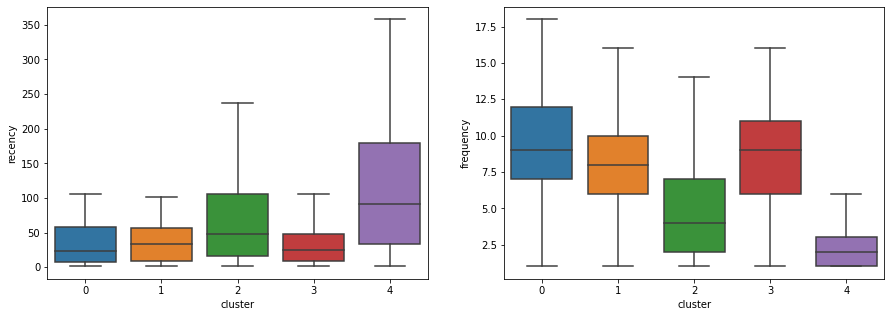

In [19]:
compare_clusters( cluster='cluster', y=['recency', 'frequency'], data=customer_abt, showfliers=0)

In [40]:
cluster_stats(customer_abt, cluster='cluster', column='recency').sort_values('mean', ascending=False)

,mean,std,min,25%,50%,75%,80%,90%,max
cluster,,,,,,,,,
4,111.202970,92.538729,2.0,34.0,90.5,179.50,188.0,254.8,358.0
2,74.074020,76.361663,1.0,16.0,48.0,105.00,121.4,187.2,363.0
3,42.985948,58.427514,1.0,9.0,25.0,48.50,59.6,100.4,353.0
0,41.202703,52.919939,1.0,8.0,23.5,58.25,63.8,88.6,288.0
1,40.067227,43.109779,1.0,9.0,33.0,56.00,60.8,76.2,308.0


### 2.4 Discount and Shipping Cost

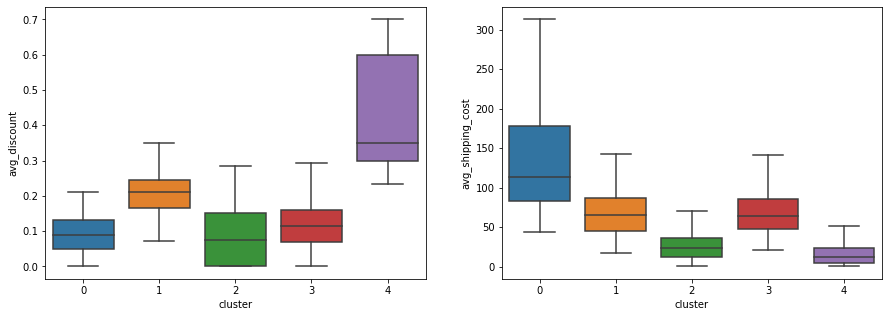

In [132]:
compare_clusters( cluster='cluster', y=['avg_discount', 'avg_shipping_cost'], data=customer_abt, showfliers=0)

In [48]:
cluster_stats(customer_abt, cluster='cluster', column='avg_discount').sort_values('mean', ascending=False)

,mean,std,min,25%,50%,75%,80%,90%,max
cluster,,,,,,,,,
4,0.436059,0.155805,0.233333,0.300000,0.350000,0.600000,0.600000,0.700000,0.700000
1,0.218106,0.083889,0.072222,0.166100,0.211111,0.245276,0.265119,0.302476,0.600000
3,0.113789,0.071246,0.000000,0.070417,0.113333,0.159550,0.167247,0.197077,0.433333
0,0.089265,0.058527,0.000000,0.048848,0.087937,0.131917,0.139648,0.152917,0.270833
2,0.084314,0.085567,0.000000,0.000000,0.075926,0.150000,0.175000,0.204362,0.283333


### 2.5 Cluster 4

The greater the discount, higher the chance of negative profit occurs.

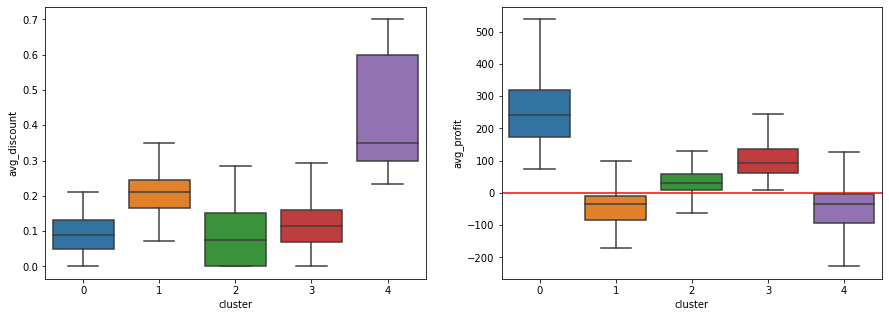

In [96]:
compare_clusters( cluster='cluster', y=['avg_discount', 'avg_profit'], data=customer_abt, showfliers=0)
plt.axhline(0, c='r');

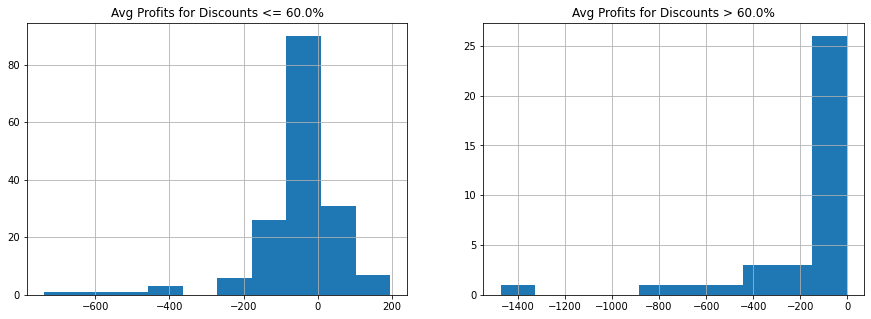

In [113]:
cluster = 4
discount = .6
fig()
plt.subplot(1,2,1)
customer_abt[(customer_abt['cluster'] == cluster) & (customer_abt['avg_discount'] <= discount)]['avg_profit'].hist()
plt.title(f"Avg Profits for Discounts <= {discount*100}%")
plt.subplot(1,2,2)
customer_abt[(customer_abt['cluster'] == cluster) & (customer_abt['avg_discount'] > discount)]['avg_profit'].hist()
plt.title(f"Avg Profits for Discounts > {discount*100}%");

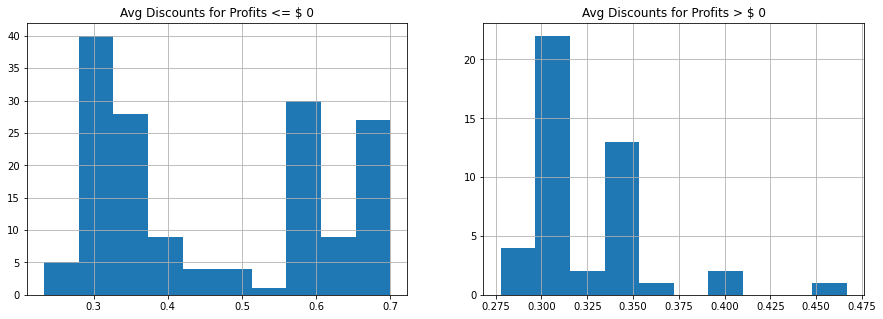

In [126]:
profit = 0
fig()
plt.subplot(1,2,1)
customer_abt[(customer_abt['cluster'] == cluster) & (customer_abt['avg_profit'] <= profit)]['avg_discount'].hist()
plt.title(f"Avg Discounts for Profits <= $ {profit}")
plt.subplot(1,2,2)
customer_abt[(customer_abt['cluster'] == cluster) & (customer_abt['avg_profit'] > profit)]['avg_discount'].hist()
plt.title(f"Avg Discounts for Profits > $ {profit}");

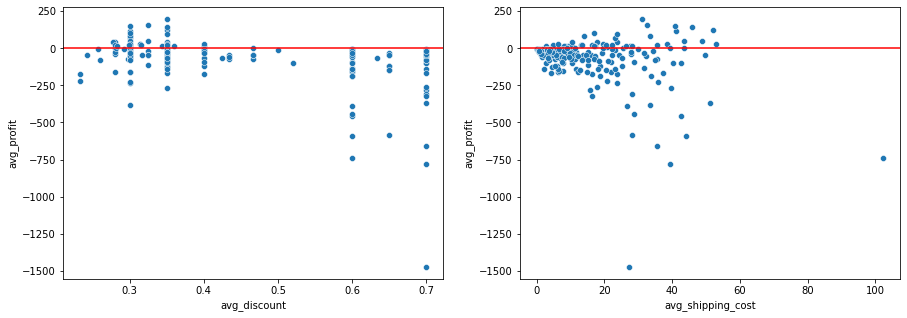

In [130]:
fig()
plt.subplot(1,2,1)
sns.scatterplot(data=customer_abt[(customer_abt['cluster'] == cluster)], x='avg_discount', y='avg_profit');
plt.axhline(0, c='r')
plt.subplot(1,2,2)
sns.scatterplot(data=customer_abt[(customer_abt['cluster'] == cluster)], x='avg_shipping_cost', y='avg_profit');
plt.axhline(0, c='r');

### 2.6 Cluster 1

Negative Profit with High and Low Values for Discount and Shipping Cost.

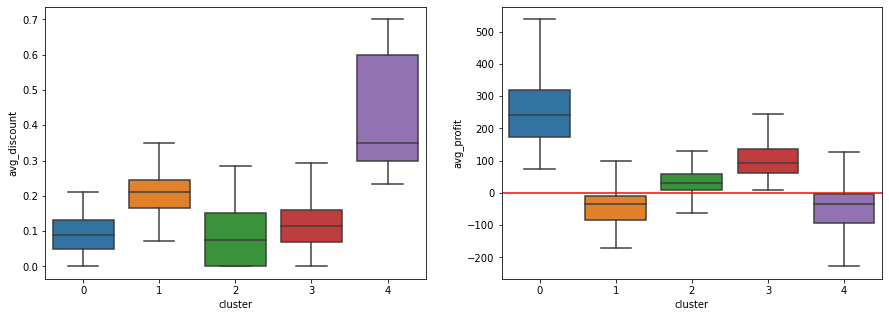

In [74]:
compare_clusters( cluster='cluster', y=['avg_discount', 'avg_profit'], data=customer_abt, showfliers=0)
plt.axhline(0, c='r');

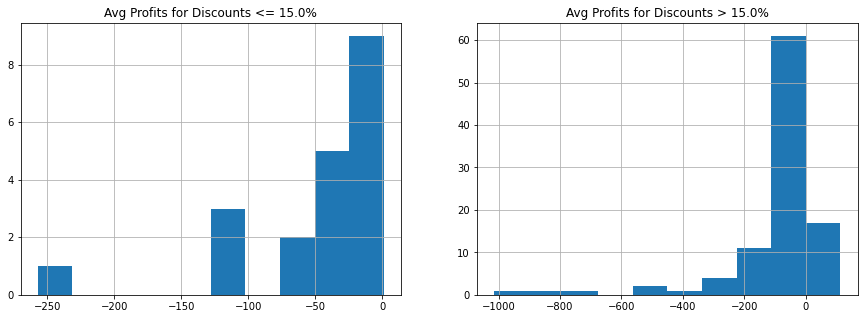

In [119]:
cluster = 1
discount = .15
fig()
plt.subplot(1,2,1)
customer_abt[(customer_abt['cluster'] == cluster) & (customer_abt['avg_discount'] <= discount)]['avg_profit'].hist()
plt.title(f"Avg Profits for Discounts <= {discount*100}%")
plt.subplot(1,2,2)
customer_abt[(customer_abt['cluster'] == cluster) & (customer_abt['avg_discount'] > discount)]['avg_profit'].hist()
plt.title(f"Avg Profits for Discounts > {discount*100}%");

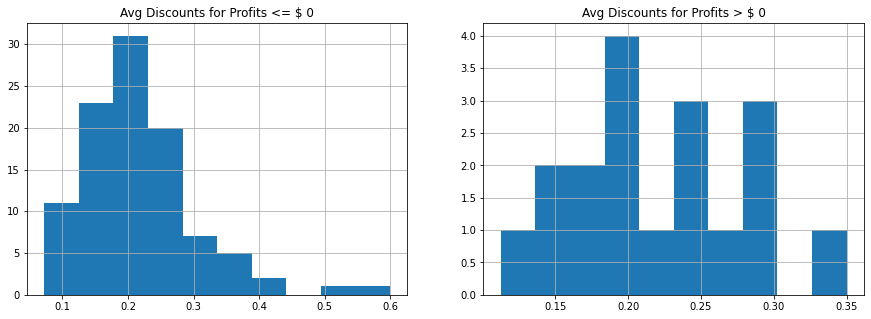

In [120]:
cluster = 1
profit = 0
fig()
plt.subplot(1,2,1)
customer_abt[(customer_abt['cluster'] == cluster) & (customer_abt['avg_profit'] <= profit)]['avg_discount'].hist()
plt.title(f"Avg Discounts for Profits <= $ {profit}")
plt.subplot(1,2,2)
customer_abt[(customer_abt['cluster'] == cluster) & (customer_abt['avg_profit'] > profit)]['avg_discount'].hist()
plt.title(f"Avg Discounts for Profits > $ {profit}");

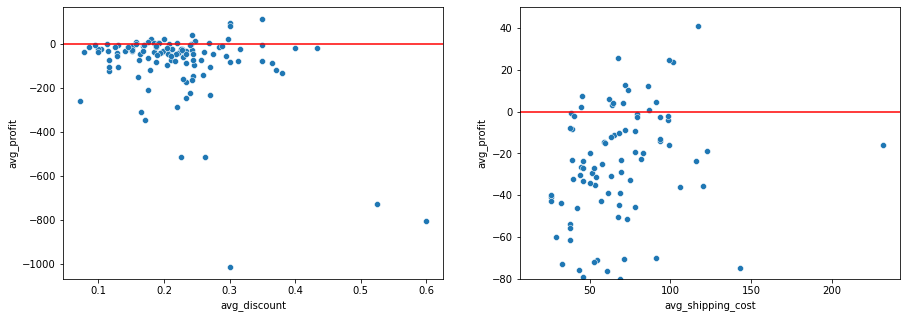

In [122]:
fig()
plt.subplot(1,2,1)
sns.scatterplot(data=customer_abt[(customer_abt['cluster'] == cluster)], x='avg_discount', y='avg_profit');
plt.axhline(0, c='r')
# plt.ylim(-80, 50);
plt.subplot(1,2,2)
sns.scatterplot(data=customer_abt[(customer_abt['cluster'] == cluster)], x='avg_shipping_cost', y='avg_profit');
plt.axhline(0, c='r')
plt.ylim(-80, 50);

## 3 Random Forest

In [23]:
x = customer_abt.drop(columns=['cluster'])[all_features]
y = customer_abt['cluster']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=0)
pd.concat([y_train.value_counts(), y_test.value_counts()], axis=1)

random_forest_model = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, random_state=0)
random_forest_model.fit(X_train, y_train)

y_pred = random_forest_model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=1))

              precision    recall  f1-score   support

           0       1.00      0.81      0.90        32
           1       0.93      0.73      0.82        52
           2       0.94      0.97      0.95       270
           3       0.91      0.98      0.94       165
           4       1.00      0.97      0.98        86

    accuracy                           0.94       605
   macro avg       0.96      0.89      0.92       605
weighted avg       0.94      0.94      0.94       605



In [25]:
features # Clustering Features

['total_sales', 'total_profit', 'avg_discount', 'avg_shipping_cost']

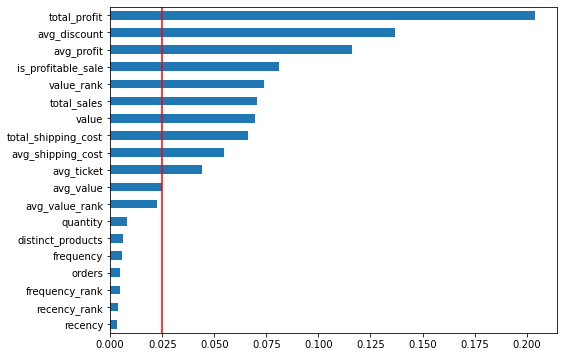

In [26]:
feature_importances = pd.Series(random_forest_model.feature_importances_, index=x.columns).sort_values(ascending=True)
feature_importances.plot.barh(figsize=(8, 6))
plt.axvline(0.025, c='r');

In [27]:
# feature_importances.tail(15).index

### 4 Objective Answers

- **Who are our best customers?**
        
        Champions:
            High Sales
            High Profit
            High Frequency


- **Where are they?**

        Due to lack of metadata We can't answer location questions accuratly.
        More on RFV Segmentation Notebook section: 3.5 Location


- **Who has the potential to become valuable customers?**
        
        Promising:
            We have margin to give discounts in order to increase sales.
            Lower sales and profit than the Loyal customers and half of
            orders.
        
        Risky Sale:
            Most purchases result in deficit (negative profit), mainly
            due to high-value discounts. Decreasing discount values
            may turn them profitable again, besides finding out the 
            exactly reason for negative profit.


- **Which of our customers are most likely to respond to engagement campaigns?**
        
        Promising: (Promotional Discount Campaign)
            Lower sales and profit than the Loyal customers and half of
            orders, as well as lower discounts.
                       

- **Which of our customers can be retained?**
    
        Risky Sale:
            We might have to give up on them, unless We optimize
            discounts and shipping costs to make profit out of 
            this group.



## 5 Strategies

Basic Overview:

    High Value: Improve Retention

    Mid Value: Improve Retention + Increase Frequency

    Low Value: Increase Frequency + Increase Profit
    
On the other Hand:

![img](../images/cluster_segmentation.png)

![img](../images/cluster_segmentation_strategies.png)


Saving Table

In [136]:
# cluster_names = {
#     0: 'Champion',
#     1: 'Danger Area',
#     2: 'Promising',
#     3: 'Loyal',
#     4: 'Risky Sale',
# }
# customer_abt['cluster'] = customer_abt['cluster'].map(cluster_names)

In [135]:
# customer_abt.reset_index()[['customer_id', 'cluster']].to_parquet(join_paths([directory.DATA_DIR, "processed", "customer_segmentation", "customer_segmentation.parquet"]))